# Ensemble evaluation for correlation

This notebook visualizes correlation results for the full L96 model and reduced models in settings mix and full. 

## Correlation Functions

For a single trajectory, the autocorrelation function (ACF) of $X_k$ at time lag $\tau$ is computed as

$$
    acf(\tau) = \frac{Cov\left(X_k(t), X_k(t+\tau)\right)}{Var(X_k)}. 
$$

The cross-correlation function (CCF) is computed between $X_k$ and $X_{k+1}$ as
$$
    ccf(\tau) = \frac{Cov(X_k(t), X_{k+1}(t+\tau))}{\sqrt{Var(X_k) \cdot Var(X_{k+1})}}.
$$

We compute ACF and CCF from a single long trajectory (10000 MTU).

## Parameterization Methods

### Polynomial Baselines
- Deterministic polynomial parameterization
- Stochastic polynomial parameterization with AR(1) noise

### Bayesian Method
- Bayesian polynomial parameterization

### Flow-Based Parameterizations
- **Flow**: standard normalizing flow with Gaussian base distribution
- **AR(1) Base Flow**: normalizing flow with AR(1) base distribution
- **Forcing flow**: conditioning includes external forcing
- **Tail flow**: normalizing flow with flexible tails (Hickling and Prangle, 2025: https://openreview.net/forum?id=Z6RsbHAJk5)
- **History flow**: conditioning includes state history

Each flow-based model is run with:
- white noise
- AR(1) noise



In [1]:
%autoreload

In [2]:
import sys
from pathlib import Path

# resolve project root (two levels up from this notebook)
PROJECT_ROOT = Path.cwd().resolve().parents[1]

SRC_DIR = PROJECT_ROOT / "src"
NOTEBOOKS_DIR = PROJECT_ROOT / "notebooks"

for p in (SRC_DIR, NOTEBOOKS_DIR):
    p_str = str(p)
    if p_str not in sys.path:
        sys.path.insert(0, p_str)

In [3]:
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from notebook_utils import save_plot

from matplotlib.lines import Line2D

## Setup

In [4]:
results_dir = PROJECT_ROOT / "results"

gcm_names = [
    "ensemble_gcm_baseline_det",
    "ensemble_gcm_baseline_ar_p",
    "ensemble_gcm_bayes",
    "ensemble_gcm_flow",
    "ensemble_gcm_ar_base_flow",
    "ensemble_gcm_forcing_flow",
    "ensemble_gcm_history_flow",
    "ensemble_gcm_tail_flow",
]
l96_name = "ensemble_l96"

output_subdir = ""

paper_figures_base_dir = (
    PROJECT_ROOT / "paper" / output_subdir / "figures" / "ensemble_evaluation"
)
paper_figures_base_dir.mkdir(parents=True, exist_ok=True)

## Process truth and ensemble in full/mix settings

**full**: $(N_{\mathrm{init}} \times N_{\mathrm{ens}} \times N_{\mathrm{models}} \times K)$ with stochastic model realizations across $(N_{\mathrm{models}})$  
**mix**: $(N_{\mathrm{init}} \times N_{\mathrm{ens}} \times 1 \times K)$ with stochastic model realizations across $(N_{\mathrm{init}} \times N_{\mathrm{ens}})$  
**truth**: $(N_{\mathrm{init}} \times 1 \times 1 \times K)$ fully resolved L96 simulations from perfect states. 

### Compute correlation functions

Use SLURM for computation because of long run time.

#### Running the computation via SLURM

1. Navigate to directory. E.g., from project root:

    ```sh
    cd notebooks/evaluation/scripts
    ```

2. Configure settings in `run_eval_correlation.sh`

3. Run SLURM job:

    ```sh
    sbatch run_eval_correlation.sh
    ```

Optional: To run the SLURM job for multiple models use: 
 ```sh
chmod +x submit_all_models_eval_correlation.sh
./submit_all_models_eval_correlation.sh
```

## Load computed correlation functions

### Load truth correlation functions

In [5]:
data_root = PROJECT_ROOT / "notebooks" / "evaluation" / "output" / "ensemble_evaluation"

In [6]:
# Load SLURM computed dataframes
pickle_path = data_root / "truth" / f"{l96_name}_correlation_truth.pkl"
df_truth = pd.read_pickle(pickle_path)

In [7]:
t = np.load(data_root / "truth" / f"{l96_name}_correlation_truth_time.npy")

### Load ensemble correlation functions 

In [8]:
# Load SLURM computed dataframes
def load_correlation_data(subdir, t=None):
    dfs = []
    for name in gcm_names:
        pickle_path = data_root / subdir / f"{name}_correlation_{subdir}.pkl"
        df = pd.read_pickle(pickle_path)
        dfs.append(df)

    t_curr = np.load(data_root / subdir / f"{name}_correlation_{subdir}_time.npy")
    if t is None:
        t = t_curr
    else:
        assert np.allclose(t, t_curr), "Time arrays do not match!"

    return pd.concat(dfs, ignore_index=True)

In [9]:
df_gcms = load_correlation_data("long", t=t)

 ## Plot correlation functions

### Plotting helpers

In [10]:
def _select_sub_df(d, model, noise_type, ar_order, delta_t):
    """
    Selects rows matching (model, noise_type, ar_order, delta_t) and returns the sub-DataFrame.

    Conventions:
      - noise_type=None, ar_order missing -> no noise
      - noise_type="white" -> white noise, ar_order treated as 0
      - noise_type="ar_p"  -> AR(p), ar_order must be p
      - baseline_ar_p special-case:
            model contains "baseline_ar_p" and noise_type is None but ar_order is int
            -> treat as baseline AR(p) even though noise_type is missing in DF

    delta_t:
      - If delta_t is None, rows must have delta_t missing (NaN)
      - If delta_t is provided, rows must match exactly
    """
    # normalize columns
    if "noise_type" not in d.columns:
        d["noise_type"] = pd.NA
    d["noise_type"] = d["noise_type"].replace("", pd.NA)

    if "ar_order" not in d.columns:
        d["ar_order"] = pd.NA
    d["ar_order"] = pd.to_numeric(d["ar_order"], errors="coerce")

    if "delta_t" not in d.columns:
        d["delta_t"] = pd.NA
    d["delta_t"] = pd.to_numeric(d["delta_t"], errors="coerce")

    m = d["model"].eq(model)

    # delta_t logic
    if delta_t is None:
        m &= d["delta_t"].isna()
    else:
        m &= d["delta_t"].eq(delta_t)

    is_baseline_ar_model = "baseline_ar_p" in str(model)

    # noise/ar logic
    if noise_type is None:
        # Require noise_type missing
        m &= d["noise_type"].isna()

        if ar_order is None:
            # true no-noise: ar_order must be missing
            m &= d["ar_order"].isna()
        else:
            # baseline_ar_p: allow missing noise_type but concrete p
            if not is_baseline_ar_model:
                raise ValueError(
                    "ar_order was provided but noise_type is None. "
                    "This is only supported for baseline_ar_p models."
                )
            m &= d["ar_order"].eq(ar_order)

    else:
        # standard noisy cases
        m &= d["noise_type"].eq(noise_type)

        if noise_type == "white":
            m &= d["ar_order"].fillna(0).eq(0)
        else:
            # AR(p)
            if ar_order is None:
                raise ValueError("ar_order must be provided when noise_type='ar_p'")
            m &= d["ar_order"].eq(ar_order)

    return d.loc[m]


def select_metric_from_df(
    df, metric, model, noise_type=None, ar_order=None, delta_t=None
):
    """
    Select the single row matching (model, noise_type, ar_order, delta_t) and
    return its stored metric array.

    Conventions:
      - noise_type=None, ar_order missing -> no noise
      - noise_type="white" -> white noise, ar_order treated as 0
      - noise_type="ar_p"  -> AR(p), ar_order must be p
      - baseline_ar_p special-case:
            model contains "baseline_ar_p" and noise_type is None but ar_order is int
            -> treat as baseline AR(p) even though noise_type is missing in DF

    delta_t:
      - If delta_t is None, rows must have delta_t missing (NaN)
      - If delta_t is provided, rows must match exactly
    """
    d = df.copy()
    sub = _select_sub_df(d, model, noise_type, ar_order, delta_t)
    if sub.empty:
        raise KeyError(
            f"No rows found for model={model}, noise_type={noise_type}, "
            f"ar_order={ar_order}, delta_t={delta_t}"
        )
    if len(sub) > 1:
        raise RuntimeError(
            f"Multiple rows found for model={model}, noise_type={noise_type}, "
            f"ar_order={ar_order}, delta_t={delta_t}. Expected exactly one."
        )

    metric_val = sub.iloc[0][metric]
    metric_val = np.asarray(metric_val, dtype=float)
    if metric not in ["rmse_t", "ancr_t", "si"] and metric_val.ndim != 2:
        raise ValueError(
            f"Expected {metric} to be 2D [time, k], got shape {metric_val.shape}"
        )
    return metric_val

In [11]:
def _parse_noise_label(noise_type: str, ar_order: int):
    if noise_type is None and isinstance(ar_order, (int, float)):
        # Polynomial case
        return f"AR({int(ar_order)})"
    elif noise_type == "ar_p":
        return f"(AR({ar_order}))"
    elif noise_type == "white":
        return "(iid)"
    else:
        raise ValueError(f"Unknown noise_type: {noise_type}")


def parse_label(
    source_name: str, noise_type: str, ar_order: int, delta_t: int, line_breaks=False
):
    line_break = "\n" if line_breaks else " "
    if source_name == "Truth":
        return "Truth"
    if source_name.startswith("ensemble_gcm_baseline_det"):
        return f"Baseline{line_break}Deterministic"
    if source_name.startswith("ensemble_gcm_baseline_ar_p"):
        base_str = "Polynomial"
        return f"{base_str} + {_parse_noise_label(noise_type, ar_order)}"
    if source_name.startswith("ensemble_gcm_bayes"):
        return "Bayesian"
    if source_name.startswith("ensemble_gcm_flow"):
        flow_str = "Flow"
        return f"{flow_str} {_parse_noise_label(noise_type, ar_order)}"
    if source_name.startswith("ensemble_gcm_ar_base_flow"):
        flow_str = f"Base AR(1){line_break}Flow"
        return f"{flow_str} {_parse_noise_label(noise_type, ar_order)}"
    if source_name.startswith("ensemble_gcm_history_flow"):
        if delta_t == 1:
            flow_str = f"History Flow{line_break}" + r"($\tau = 1$)"
        elif delta_t == 2:
            flow_str = f"History Flow{line_break}" + r"($\tau = 2$)"
        else:
            raise RuntimeError(f"Unexpected delta_t value: {delta_t}")
        return f"{flow_str} {_parse_noise_label(noise_type, ar_order)}"
    if source_name.startswith("ensemble_gcm_forcing_flow"):
        flow_str = f"Forcing Flow{line_break}"
        return f"{flow_str} {_parse_noise_label(noise_type, ar_order)}"
    if source_name.startswith("ensemble_gcm_tail_flow"):
        flow_str = f"Tail Flow{line_break}"
        return f"{flow_str} {_parse_noise_label(noise_type, ar_order)}"

    raise RuntimeError(f"Unexpected model type: {source_name}")


MODEL_ORDER_DEFAULT = [
    "ensemble_gcm_baseline_det",
    "ensemble_gcm_baseline_ar_p-1",
    "ensemble_gcm_bayes",
    "ensemble_gcm_flow-white",
    "ensemble_gcm_flow-ar_p-1",
    "ensemble_gcm_ar_base_flow-white",
    "ensemble_gcm_ar_base_flow-ar_p-1",
    "ensemble_gcm_forcing_flow-white",
    "ensemble_gcm_forcing_flow-ar_p-1",
    "ensemble_gcm_history_flow-delta_t_1-white",
    "ensemble_gcm_history_flow-delta_t_1-ar_p-1",
    "ensemble_gcm_history_flow-delta_t_2-white",
    "ensemble_gcm_history_flow-delta_t_2-ar_p-1",
    "ensemble_gcm_tail_flow-white",
    "ensemble_gcm_tail_flow-ar_p-1",
]
MODEL_ORDER = MODEL_ORDER_DEFAULT


REDUCED_MODEL_ORDER = [
    "ensemble_gcm_baseline_det",
    "ensemble_gcm_baseline_ar_p-1",
    "ensemble_gcm_bayes",
    "ensemble_gcm_flow-white",
    "ensemble_gcm_flow-ar_p-1",
    "ensemble_gcm_history_flow-delta_t_1-white",
    "ensemble_gcm_history_flow-delta_t_1-ar_p-1",
    "ensemble_gcm_history_flow-delta_t_2-white",
    "ensemble_gcm_history_flow-delta_t_2-ar_p-1",
    "ensemble_gcm_ar_base_flow-white",
    "ensemble_gcm_ar_base_flow-ar_p-1",
    "ensemble_gcm_tail_flow-white",
    "ensemble_gcm_tail_flow-ar_p-1",
]


REDUCED_MODEL_ORDER_SELECTED = [
    "ensemble_gcm_baseline_det",
    "ensemble_gcm_baseline_ar_p-1",
    "ensemble_gcm_bayes",
    "ensemble_gcm_flow-ar_p-1",
    "ensemble_gcm_history_flow-delta_t_1-ar_p-1",
    "ensemble_gcm_ar_base_flow-ar_p-1",
]


def model_order_to_query(order_key: str):
    """
    Parse MODEL_ORDER key into:
      (model, noise_type, ar_order, delta_t)

    Missing fields are returned as None.
    """
    model_base = order_key
    noise_type = None
    ar_order = None
    delta_t = None

    # delta_t (only for history_flow keys)
    m = re.search(r"-delta_t_(\d+)", model_base)
    if m:
        delta_t = int(m.group(1))
        model_base = model_base.replace(m.group(0), "")

    # flow/ar_p keys like "..._flow-ar_p-2"
    m = re.search(r"-ar_p-(\d+)", model_base)
    if m:
        ar_order = int(m.group(1))
        noise_type = "ar_p"
        model_base = model_base.replace(m.group(0), "")

    # baseline stochastic "..._baseline_ar_p-2"
    m = re.search(r"_ar_p-(\d+)", model_base)
    if m:
        ar_order = int(m.group(1))
        model_base = model_base.replace(m.group(0), "_ar_p")

    # white noise suffix
    if model_base.endswith("-white"):
        noise_type = "white"
        model_base = model_base.removesuffix("-white")
        ar_order = 0

    return model_base, noise_type, ar_order, delta_t


def _sel_tk(arr_tk, k=None):
    a = np.asarray(arr_tk)
    return a[:, k] if k is not None else a.mean(axis=1)


In [12]:
# Build colorblind palette once
def set_model_order(model_order):
    global MODEL_ORDER, COLOR_MAP
    MODEL_ORDER = model_order
    _palette = sns.color_palette("colorblind", n_colors=len(MODEL_ORDER))
    COLOR_MAP = dict(zip(MODEL_ORDER, _palette))

In [13]:
# colorblind-safe palette
_palette = sns.color_palette("colorblind", n_colors=len(MODEL_ORDER))
COLOR_MAP = dict(zip(MODEL_ORDER, _palette))

In [14]:
TEXT_WIDTH = 6.75
SLIDE_WIDTH = 13.333  # inches, standard 16:9 PPT
SLIDE_HEIGHT = 7.5


def scaled_fontsize(fontsize, figsize_width, which_base_width):
    if which_base_width == "text":
        base_width = TEXT_WIDTH * 1.2
        power = 1.0
    elif which_base_width == "column":
        base_width = TEXT_WIDTH
        power = 1.0
    elif which_base_width == "slide":
        base_width = SLIDE_WIDTH
        power = 0.6
    elif which_base_width == "slide_column":
        base_width = (
            8.0  # empirically chosen "half slide" width that looks good with power=0.6
        )
        power = 0.6
    else:
        raise ValueError(f"Unexpected which_base_width: {which_base_width}")

    return fontsize * (figsize_width / base_width) ** power

### Plot autocorrelation function

In [15]:
def plot_correlation_grid(
    df,
    df_truth,
    corr_kind="ccf",  # "ccf" or "acf"
    models_to_plot=None,
    parse_label=parse_label,
    MODEL_ORDER=MODEL_ORDER,
    COLOR_MAP=COLOR_MAP,
    figsize=(15, 12),
    time_values=t,
    t_stop=None,
    ncols=3,
    k=None,
    bbox_to_anchor=(1.0, 0.99),
    legend_cols=1,
    legend_loc="upper left",
    which_base_width="text",
    title_line_breaks=False,
    show_legend=True,
):
    """
    Grid plot: one subplot per model, showing truth (black) and model (color)
    for either ACF or CCF.

    Parameters
    ----------
    df : pd.DataFrame
        Model dataframe, e.g. df_full or df_mix. Must contain:
        ['model', 'noise_type', 'ar_order', 'delta_t', 'truth_config_key', corr_kind]

    df_truth : pd.DataFrame
        Truth dataframe. Must contain:
        ['model', 'truth_config_key', corr_kind]

    corr_kind : {"acf", "ccf"}
        Which correlation to plot.

    k : int or None
        If metric arrays are [T, K]:
          - k is None -> mean over K
          - k is int  -> select that K index
        If metric arrays are [T], they are used directly.
    """

    if corr_kind not in {"acf", "ccf"}:
        raise ValueError("corr_kind must be either 'acf' or 'ccf'")

    sns.set_theme(
        style="white",
        rc={
            "axes.titlesize": scaled_fontsize(11, figsize[0], which_base_width),
            "axes.labelsize": scaled_fontsize(9, figsize[0], which_base_width),
            "xtick.labelsize": scaled_fontsize(9, figsize[0], which_base_width),
            "ytick.labelsize": scaled_fontsize(9, figsize[0], which_base_width),
            "legend.fontsize": scaled_fontsize(10, figsize[0], which_base_width),
            "legend.title_fontsize": scaled_fontsize(10, figsize[0], which_base_width),
        },
    )

    lw_model = 1.3
    lw_truth = 1.6

    g = df.copy()
    gt = df_truth.copy()

    if g.empty:
        raise ValueError("df is empty")
    if gt.empty:
        raise ValueError("df_truth is empty")

    def _sel_tk(arr, k=None):
        """Handle [T] or [T, K] arrays."""
        arr = np.asarray(arr)
        if arr.ndim == 2:
            if k is None:
                return np.nanmean(arr, axis=1)
            return arr[:, k]
        raise ValueError(f"Expected 1D or 2D array, got shape {arr.shape}")

    # infer T from first non-null truth entry
    first_var = next(v for v in gt[corr_kind] if v is not None)
    T = len(_sel_tk(first_var, k=k))

    # x-axis
    if time_values is None:
        x_full = np.arange(T)
        x_label = "Lag index"
    else:
        x_full = np.asarray(time_values)
        x_label = "Lag"

    if len(x_full) != T:
        raise ValueError(
            f"time_values has length {len(x_full)}, but metric length is {T}"
        )

    mask = np.ones(T, dtype=bool) if t_stop is None else (x_full <= t_stop)
    x = x_full[mask]

    # choose models
    keys = []
    for order_key in MODEL_ORDER:
        model, noise, ar_order, delta_t = model_order_to_query(order_key)
        if (
            models_to_plot is None
            or order_key in models_to_plot
            or model in models_to_plot
        ):
            keys.append(order_key)

    if not keys:
        raise ValueError("No matching models_to_plot found")

    n = len(keys)
    nrows = int(np.ceil(n / ncols))

    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=figsize,
        sharex=True,
        sharey=True,
        constrained_layout=True,
    )
    axes = np.atleast_2d(axes)

    for idx, order_key in enumerate(keys):
        r, c = divmod(idx, ncols)
        ax = axes[r, c]

        model, noise, ar_order, delta_t = model_order_to_query(order_key)

        color = COLOR_MAP.get(order_key, None)
        title = parse_label(
            model, noise, ar_order, delta_t, line_breaks=title_line_breaks
        )

        # select metric
        model_corr = select_metric_from_df(
            g, corr_kind, model, noise_type=noise, ar_order=ar_order, delta_t=delta_t
        )
        true_corr = gt.iloc[0][corr_kind]

        # handle k selection and 2D->1D reduction
        y_true = _sel_tk(true_corr, k=k)[mask]
        y_model = _sel_tk(model_corr, k=k)[mask]

        # plot
        ax.plot(x, y_true, color="black", lw=lw_truth, label="Truth")
        ax.plot(
            x,
            y_model,
            color=color,
            lw=lw_model,
            label=parse_label(model, noise, ar_order, delta_t, line_breaks=False),
        )

        ax.set_title(title)
        ax.tick_params(axis="both", bottom=True, left=True, length=3)
        ax.set_xmargin(0.02)

        if r == nrows - 1:
            ax.set_xlabel(x_label)
            ax.tick_params(axis="x", bottom=True, length=5)
            x_tick_labels = (
                [0, 1, 2, 3, 4, 5]
                if t_stop == 5
                else [0, 2, 4, 6, 8, 10]
                if t_stop == 10
                else [0, 5, 10, 15, 20]
                if t_stop == 20
                else ax.get_xticks()
            )
            ax.set_xticks(x_tick_labels)
            ax.set_xticklabels(x_tick_labels)
        if c == 0:
            ax.set_ylabel(corr_kind.upper())
            ax.tick_params(axis="y", left=True, length=5)

    # hide empty axes
    for j in range(n, nrows * ncols):
        rr, cc = divmod(j, ncols)
        axes[rr, cc].axis("off")

    if show_legend:
        # just do a simple truth vs model legend to avoid overcrowding
        legend_handles = [
            Line2D([0], [0], color="black", lw=lw_truth, label="Truth (black)"),
            Line2D([0], [0], color="gray", lw=lw_model, label="Model (color)"),
        ]

        fig.legend(
            handles=legend_handles,
            loc=legend_loc,
            bbox_to_anchor=bbox_to_anchor,
            ncols=legend_cols,
            frameon=True,
        )

    return fig

#### Paper ready plot

In [16]:
paper_f_dir_l = paper_figures_base_dir / "long"
paper_f_dir_l.mkdir(parents=True, exist_ok=True)
print(f"Saving long to figures dir: {Path(*paper_f_dir_l.parts[-4:])}")

Saving long to figures dir: paper/figures/ensemble_evaluation/long


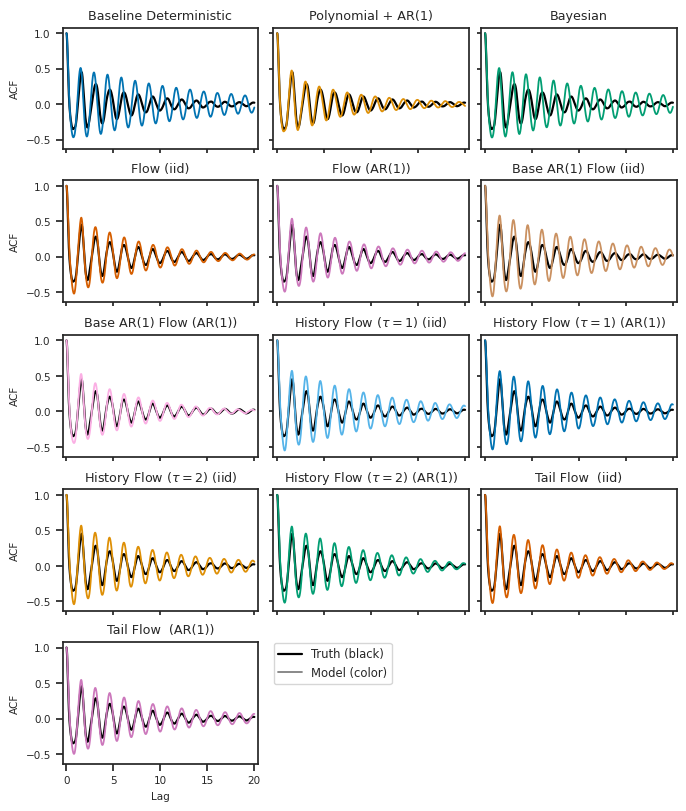

In [17]:
set_model_order(REDUCED_MODEL_ORDER)

t_stop = 20
k = None
corr_kind = "acf"

fig = plot_correlation_grid(
    df=df_gcms,
    df_truth=df_truth,
    corr_kind=corr_kind,
    k=k,
    models_to_plot=REDUCED_MODEL_ORDER,
    ncols=3,
    t_stop=t_stop,
    bbox_to_anchor=(0.58, 0.21),
    figsize=(TEXT_WIDTH, 8),
    legend_loc="upper right",
    legend_cols=1,
    which_base_width="text",
)
plt.show()
k_str = "avg_k" if k is None else k

fig.savefig(
    paper_f_dir_l / f"{corr_kind}_grid_t{t_stop}_k_{k_str}.pdf",
    bbox_inches="tight",
    pad_inches=0.1,
    format="pdf",
)

# reset model
set_model_order(MODEL_ORDER_DEFAULT)

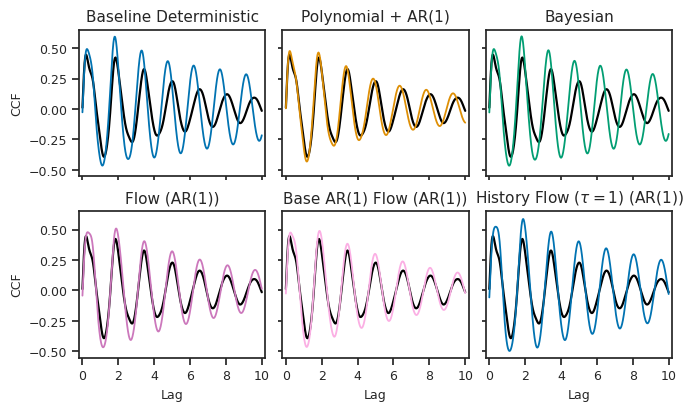

In [18]:
set_model_order(REDUCED_MODEL_ORDER_SELECTED)

t_stop = 10
k = None
corr_kind = "ccf"

fig = plot_correlation_grid(
    df=df_gcms,
    df_truth=df_truth,
    corr_kind=corr_kind,
    k=k,
    models_to_plot=REDUCED_MODEL_ORDER_SELECTED,
    ncols=3,
    t_stop=t_stop,
    bbox_to_anchor=(1.0, 0),
    figsize=(TEXT_WIDTH, 4),
    legend_loc="upper right",
    legend_cols=2,
    which_base_width="column",
    show_legend=False,
)

plt.show()
k_str = "avg_k" if k is None else k
fig.savefig(
    paper_f_dir_l / f"{corr_kind}_grid_t{t_stop}_k_{k_str}_selected.pdf",
    bbox_inches="tight",
    pad_inches=0.1,
    format="pdf",
)
# reset model
set_model_order(MODEL_ORDER_DEFAULT)